In [1]:
#undef __noinline__

# GPU Ripple Pattern

This notebook demonstrates GPU parallelism using a 2D ripple pattern rendered on the GPU.

## How It Works

Each pixel is assigned to one GPU thread using a 2D launch grid. The thread computes a
grayscale value based on the pixel's distance from the image centre, producing
concentric rings that fade with distance.

### The Kernel

The kernel maps thread and block indices to a 2D pixel position:
```cpp
int x = threadIdx.x + blockIdx.x * blockDim.x;
int y = threadIdx.y + blockIdx.y * blockDim.y;
```

It then computes the Euclidean distance from the centre and feeds it into a cosine wave:
```
color = 42 + 127 * cos(dist / 10) / (dist / 10 + 1)
```

- `dist` — distance from the image centre  
- The denominator `(dist/10 + 1)` attenuates the wave amplitude with distance, giving a natural fall-off

In [2]:
#define GRID 512

__global__ void ripple(unsigned char *fb) {
    int x = threadIdx.x + blockIdx.x * blockDim.x;
    int y = threadIdx.y + blockIdx.y * blockDim.y;
    int idx = x + y * blockDim.x * gridDim.x;

    // Vector from pixel to image centre
    float dx = x - GRID / 2.0f;
    float dy = y - GRID / 2.0f;
    float d_sq = dx * dx + dy * dy;

    // Hardware sqrt and cos via PTX intrinsics
    float dist, cos_val;
    asm("sqrt.rn.f32 %0, %1;" : "=f"(dist) : "f"(d_sq));
    float ang = dist / 10.0f;
    asm("cos.approx.f32 %0, %1;" : "=f"(cos_val) : "f"(ang));

    unsigned char color = (unsigned char)(42 + 127.0f * cos_val / (ang + 1.0f));

    fb[idx * 4 + 0] = color;
    fb[idx * 4 + 1] = color;
    fb[idx * 4 + 2] = color;
    fb[idx * 4 + 3] = 255;
}

### Launch Configuration

The image is `512 × 512` pixels, divided into `16 × 16` thread blocks.
The kernel launches `32 × 32 = 1024` blocks with `256` threads each — one thread per pixel.

In [3]:
#define STB_IMAGE_WRITE_IMPLEMENTATION
#include "headers/stb_image_write.h"

unsigned char *d_fb;
cudaMalloc(&d_fb, GRID * GRID * 4);

dim3 block(16, 16);
dim3 grid(GRID / 16, GRID / 16);

ripple<<<grid, block>>>(d_fb);

cudaDeviceSynchronize();

unsigned char h_fb[GRID * GRID * 4];
cudaMemcpy(h_fb, d_fb, GRID * GRID * 4, cudaMemcpyDeviceToHost);

stbi_write_png("images/ripple.png", GRID, GRID, 4, h_fb, GRID * 4);

cudaFree(d_fb);

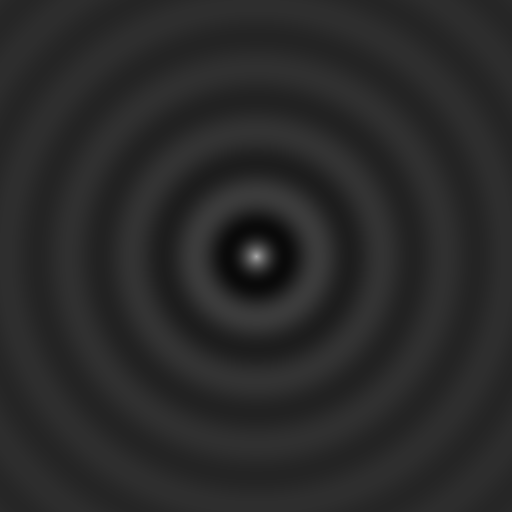

In [4]:
#include "headers/display.hpp"

im::image ripple_image("images/ripple.png");
xcpp::display(ripple_image);